# MPG Dataset Analysis

## Overview

This notebook explores the MPG (Miles Per Gallon) dataset to understand the factors affecting vehicle fuel efficiency.

The analysis includes:

- Data Overview
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Data Visualization
- Business Insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.rcParams["figure.figsize"] = (8,5)

## Load Dataset

The MPG dataset contains information about fuel efficiency and technical specifications of vehicles manufactured between 1970 and 1982.

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


## Data Overview

Before performing analysis, it is important to understand the dataset structure, variable types, and identify potential missing values.

In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0
name,0


## Data Cleaning

Rows with missing values in important variables are removed to ensure reliable analysis.

In [4]:
df = df.dropna(
    subset=[
        "mpg",
        "horsepower",
        "weight",
        "cylinders",
        "origin",
        "model_year"
    ]
)
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin        392 non-null    object 
 8   name          392 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 30.6+ KB


,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model_year,0
origin,0
name,0


# Exploratory Data Analysis
### Distribution of Fuel Efficiency

This histogram illustrates the distribution of vehicle fuel efficiency (MPG).

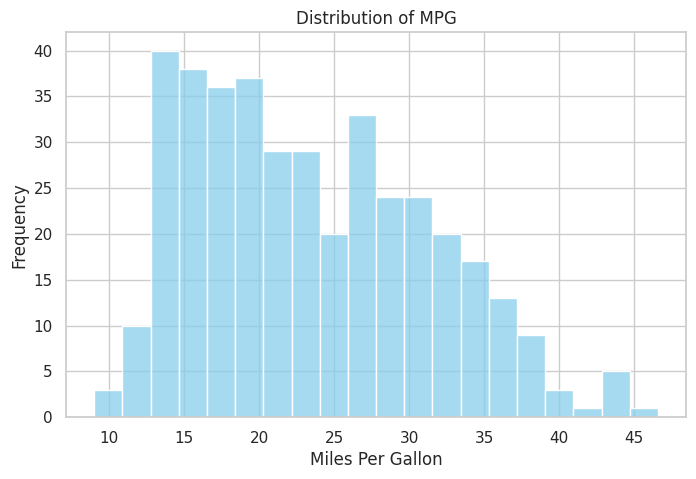

In [5]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="mpg",
    bins=20,
    color="skyblue"
)

plt.title("Distribution of MPG")
plt.xlabel("Miles Per Gallon")
plt.ylabel("Frequency")

plt.show()

### Vehicle Weight vs Fuel Efficiency

This scatter plot shows the relationship between vehicle weight and fuel efficiency.

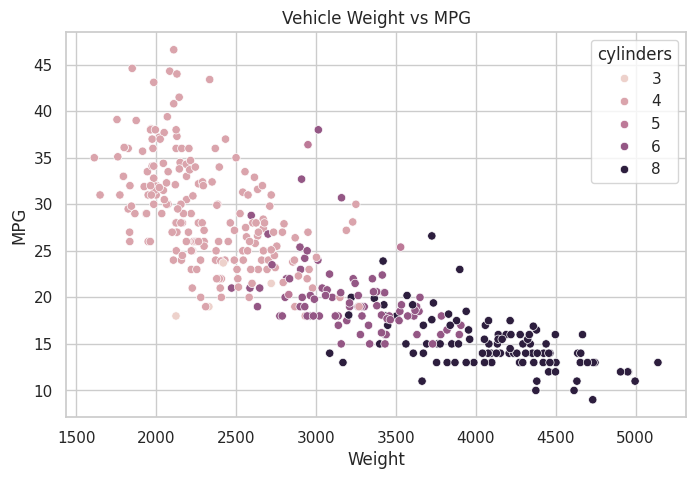

In [6]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="weight",
    y="mpg",
    hue="cylinders"
)

plt.title("Vehicle Weight vs MPG")

plt.xlabel("Weight")

plt.ylabel("MPG")

plt.show()

### Fuel Efficiency Trend

Average MPG is calculated for each production year.

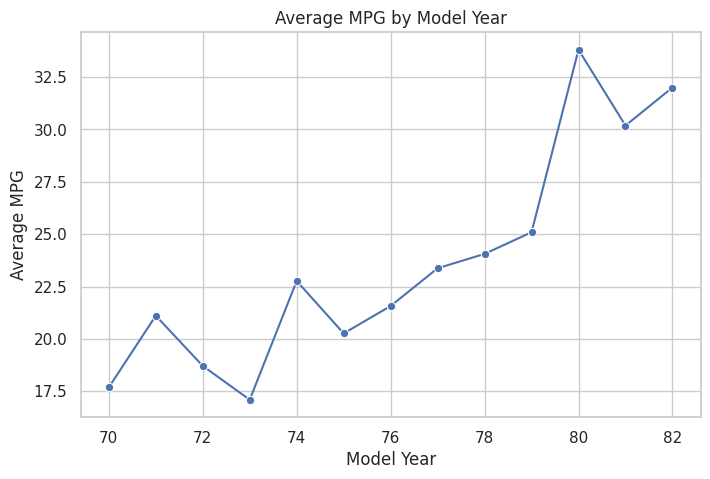

In [7]:
avg = (
    df.groupby("model_year")["mpg"]
    .mean()
    .reset_index()
)
plt.figure(figsize=(8,5))

sns.lineplot(
    data=avg,
    x="model_year",
    y="mpg",
    marker="o"
)

plt.title("Average MPG by Model Year")

plt.xlabel("Model Year")

plt.ylabel("Average MPG")

plt.show()

# Key Insights

### 1. Distribution of MPG

- Vehicles generally have fuel efficiency ranging between 15 and 35 MPG.
- Japanese and European vehicles tend to achieve higher MPG than American vehicles.

---

### 2. Relationship Between Weight and MPG

- Vehicle weight has a strong negative relationship with MPG.
- Heavier vehicles generally consume more fuel.
- Four-cylinder vehicles tend to have the highest fuel efficiency.

---

### 3. Fuel Efficiency Trend

- Average MPG steadily increased from 1970 to 1982.
- The improvement became more noticeable after 1976.
- This suggests continuous technological improvements in engine efficiency.

# Conclusion

This analysis indicates that vehicle weight is one of the most influential factors affecting fuel efficiency.

The findings also reveal a long-term improvement in fuel efficiency between 1970 and 1982, reflecting advancements in automotive technology.

Among the three origins, Japanese vehicles generally demonstrate better fuel efficiency than American vehicles, while European vehicles also perform relatively well.